In [ ]:
import pandas as pd


# Load the first CSV file
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Load the second CSV file
subject_metadata_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/subject_metadata.csv"
subject_metadata = pd.read_csv(subject_metadata_path)


# Number of unique UserIds in train_data
num_user_ids = train_data['UserId'].nunique()

# Number of questions answered
num_questions_answered = len(train_data)

# Number of unique concepts answered
num_concepts_answered = train_data['Concept'].nunique()

print(f"Number of UserIds: {num_user_ids}")
print(f"Number of questions answered: {num_questions_answered}")
print(f"Number of concepts answered: {num_concepts_answered}")

print("Columns in train_task_3_4_with_concept:", train_data.columns)
print("Columns in subject_metadata:", subject_metadata.columns)



In [ ]:
# ایجاد یک مجموعه از مفاهیم موجود در train_data
train_data_concepts = set(train_data['Concept'].unique())

# ایجاد یک مجموعه از مفاهیم موجود در subject_metadata
subject_metadata_concepts = set(subject_metadata['SubjectId'])

# چک کردن مفاهیم وجود دار در train_data اما در subject_metadata ندارند
missing_concepts = train_data_concepts - subject_metadata_concepts

# چاپ مفاهیمی که در train_data وجود دارند اما در subject_metadata ندارند
print("Missing Concepts in subject_metadata:", missing_concepts)

# چاپ یک نمونه از train_data برای بررسی اطلاعات
print(train_data.head())


In [ ]:
# افزودن اطلاعات مفاهیم به subject_metadata

for concept_id in missing_concepts:

    # اطلاعات مفاهیم موجود در train_data را بازیابی کنید
    concept_info = train_data[train_data['Concept'] == concept_id].iloc[0]

    # اضافه کردن اطلاعات به subject_metadata
    subject_metadata.loc[len(subject_metadata.index)] = {'SubjectId': concept_info['Concept'], 'Name': concept_info['Concept']}


# چاپ subject_metadata بعد از اضافه کردن اطلاعات
print(subject_metadata)

In [ ]:
import random
import pandas as pd
import os

# Load the train data
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Get unique concepts from the train data
answered_concepts = train_data['Concept'].unique()

# Filter the data to include only rows with answered concepts
filtered_data = train_data[train_data['Concept'].isin(answered_concepts)]

# Group by UserId
grouped_data = filtered_data.groupby('UserId')

# Create Episodes
episodes = []

for _, group in grouped_data:
    # Use all questions for each user with answered concepts
    episode = group.copy()
    episodes.append(episode)

# Save Episodes (between 6000 and 8000)
num_available_episodes = len(episodes)
num_episodes = min(random.randint(6000, 8000), num_available_episodes)

selected_episodes = random.sample(episodes, num_episodes)
selected_episodes_df = pd.concat(selected_episodes)

# Change 'your_absolute_path' to the actual path where you have write permission
os.chdir('C:/Users/malih/OneDrive/Desktop/code1/Final')
selected_episodes_df.to_csv('Episode.csv', index=False)


## **Random:**

Episode: 1, Accuracy: 4/10=0.4, Reward: 4
Episode: 2, Accuracy: 4/10=0.4, Reward: 4
Episode: 3, Accuracy: 4/10=0.4, Reward: 4
Episode: 4, Accuracy: 6/10=0.6, Reward: 6
Episode: 5, Accuracy: 6/10=0.6, Reward: 6
Episode: 6, Accuracy: 5/10=0.5, Reward: 5
Episode: 7, Accuracy: 4/10=0.4, Reward: 4
Episode: 8, Accuracy: 6/10=0.6, Reward: 6
Episode: 9, Accuracy: 4/10=0.4, Reward: 4
Episode: 10, Accuracy: 6/10=0.6, Reward: 6
Episode: 11, Accuracy: 5/10=0.5, Reward: 5
Episode: 12, Accuracy: 6/10=0.6, Reward: 6
Episode: 13, Accuracy: 5/10=0.5, Reward: 5
Episode: 14, Accuracy: 3/10=0.3, Reward: 3
Episode: 15, Accuracy: 5/10=0.5, Reward: 5
Episode: 16, Accuracy: 7/10=0.7, Reward: 7
Episode: 17, Accuracy: 7/10=0.7, Reward: 7
Episode: 18, Accuracy: 4/10=0.4, Reward: 4
Episode: 19, Accuracy: 4/10=0.4, Reward: 4
Episode: 20, Accuracy: 4/10=0.4, Reward: 4
Episode: 21, Accuracy: 6/10=0.6, Reward: 6
Episode: 22, Accuracy: 4/10=0.4, Reward: 4
Episode: 23, Accuracy: 4/10=0.4, Reward: 4
Episode: 24, Accurac

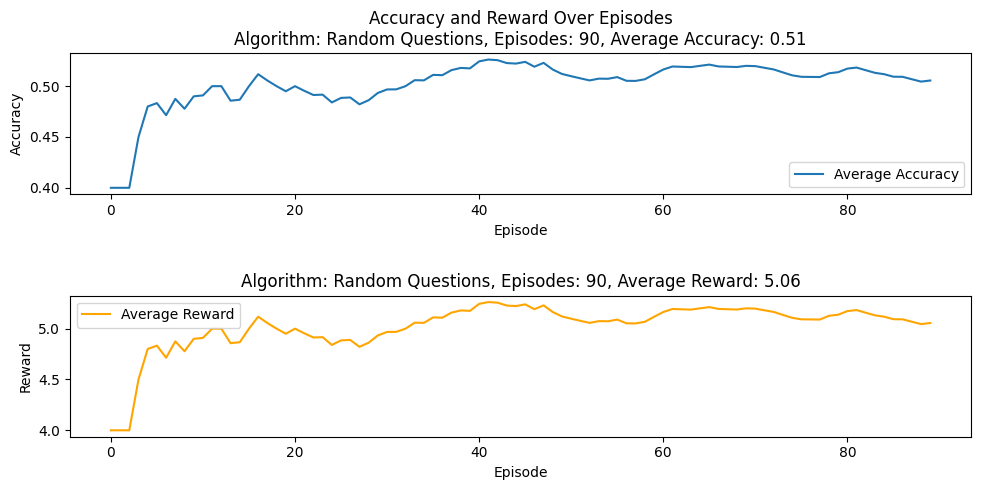

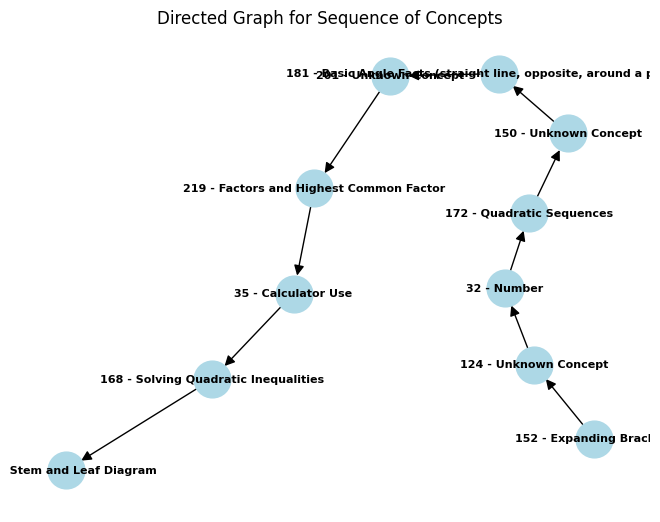

In [12]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Load subject metadata from the CSV file
subject_metadata = pd.read_csv('subject_metadata.csv')

# Extract the relevant columns
concept_names = dict(zip(subject_metadata['SubjectId'], subject_metadata['Name']))

# Load the train data
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Get unique concepts from the train data
unique_concepts = train_data['Concept'].unique()

# Select 10 random concepts for the graph
selected_concepts = random.sample(list(unique_concepts), 11)

# Create a graph representing the chain of concepts
graph = {selected_concepts[i]: selected_concepts[i + 1] for i in range(10)}

# Variables to track accuracy and reward for each episode
episode_accuracies = []
episode_rewards = []

# Initialize lists to store average accuracy and total reward for each episode
average_accuracy_episodes = []
average_reward_episodes = []

# Initialize total accuracy and total reward for each episode
total_accuracy_episode = 0
total_reward_episode = 0

# Q-learning algorithm
num_episodes = 90

# Initialize Q-values dictionary
q_values = {}

for episode in range(num_episodes):
    state = selected_concepts[0]  # Initial state
    episode_accuracy = 0
    episode_reward = 0

    while state != selected_concepts[-1]:  # Continue until reaching the last state
        # Select 10 random questions related to the selected concept
        concept_questions = train_data[train_data['Concept'] == state]
        concept_questions = concept_questions.sample(10, replace=True)  # Select 10 questions randomly with replacement

        # Choose a random question from the selected questions
        question_data = concept_questions.sample(1).iloc[0]
        student_answer = question_data['AnswerValue']

        # Calculate reward based on correctness of the student's answer
        reward = 1 if question_data['IsCorrect'] == 1 else 0

        # Q-value update logic (you might need to adjust this based on your specific Q-learning implementation)
        # For example, you can use the Q-learning update equation: Q(s, a) = Q(s, a) + alpha * (reward + gamma * max(Q(s', a')) - Q(s, a))
        # Make sure to update the Q-values dictionary accordingly

        # Update total accuracy and total reward for each episode
        episode_accuracy += reward
        episode_reward += reward

        # Move to the next state
        state = graph[state]


        
    # Update total accuracy and total reward for each episode
    total_accuracy_episode += episode_accuracy / (len(selected_concepts) - 1)
    total_reward_episode += episode_reward
    average_accuracy_episode = total_accuracy_episode / (episode + 1)
    average_reward_episode = total_reward_episode / (episode + 1)

    # Append average accuracy and total reward to lists for plotting
    average_accuracy_episodes.append(average_accuracy_episode)
    average_reward_episodes.append(average_reward_episode)

    # Print accuracy and reward at the end of each episode
    print(f"Episode: {episode + 1}, Accuracy: {episode_accuracy}/{len(selected_concepts) - 1}={episode_accuracy / (len(selected_concepts) - 1):.1f}, Reward: {episode_reward}")

# Print average accuracy and average total reward at the end
print(f"\nAverage Accuracy Over Episodes: {average_accuracy_episode:.2f}")
print(f"Average Total Reward Over Episodes: {average_reward_episode:.2f}")

# Create a new figure for the combined accuracy and reward plot
plt.figure(figsize=(10, 5))

# Plot accuracy over episodes
plt.subplot(2, 1, 1)
plt.plot(average_accuracy_episodes, label='Average Accuracy')
plt.title(f'Accuracy and Reward Over Episodes\nAlgorithm: Random Questions, Episodes: {num_episodes}, Average Accuracy: {average_accuracy_episode:.2f}')

plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()

# Plot reward over episodes with orange color
plt.subplot(2, 1, 2)
plt.plot(average_reward_episodes, color='orange', label='Average Reward')
plt.title(f'\nAlgorithm: Random Questions, Episodes: {num_episodes}, Average Reward: {average_reward_episode:.2f}')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()

plt.tight_layout()
plt.show()

# Create the directed graph for the sequence of selected concepts
edges = [(selected_concepts[i], selected_concepts[i + 1]) for i in range(10)]
G = nx.DiGraph(edges)

# Plot the directed graph for the sequence of concepts
pos = nx.spring_layout(G)
labels = {concept: f"{concept} - {concept_names.get(concept, 'Unknown Concept')}" for concept in selected_concepts}
nx.draw(G, pos, with_labels=True, labels=labels, node_size=700, node_color='lightblue', font_size=8, font_color='black', font_weight='bold', arrowsize=15)
plt.title('Directed Graph for Sequence of Concepts')
plt.show()


# Save the trained Q-values to a CSV file
q_values_df = pd.DataFrame(list(q_values.items()), columns=['State_Action', 'Q-Value'])
q_values_df.to_csv('9-Random_trained_qlearning.csv', index=False)

## *Random*
## *for 10 RUNs*

Run: 1, Episode: 1, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 2, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 3, Accuracy: 8/10=0.8, Reward: 8
Run: 1, Episode: 4, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 5, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 6, Accuracy: 8/10=0.8, Reward: 8
Run: 1, Episode: 7, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 8, Accuracy: 9/10=0.9, Reward: 9
Run: 1, Episode: 9, Accuracy: 8/10=0.8, Reward: 8
Run: 1, Episode: 10, Accuracy: 7/10=0.7, Reward: 7
Run: 1, Episode: 11, Accuracy: 3/10=0.3, Reward: 3
Run: 1, Episode: 12, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 13, Accuracy: 6/10=0.6, Reward: 6
Run: 1, Episode: 14, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 15, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 16, Accuracy: 7/10=0.7, Reward: 7
Run: 1, Episode: 17, Accuracy: 6/10=0.6, Reward: 6
Run: 1, Episode: 18, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 19, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 20, Accuracy: 2/10=0.2,

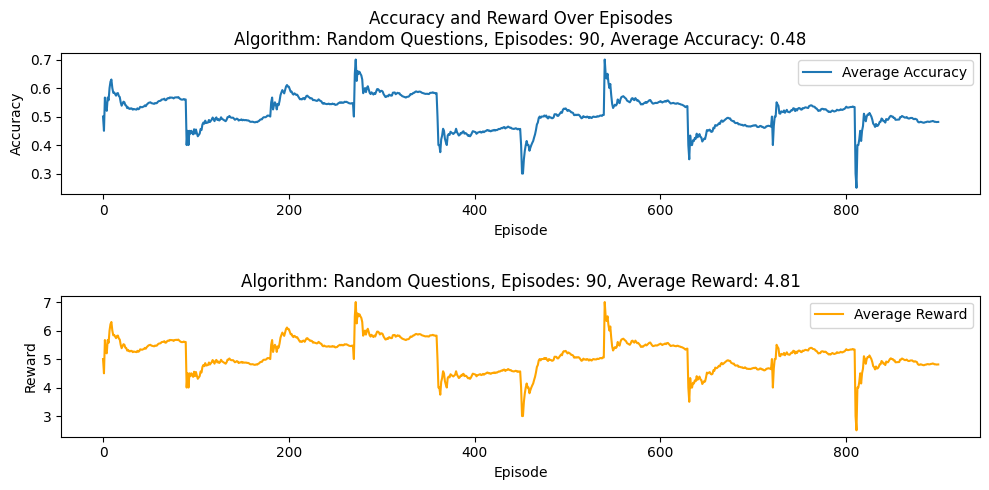

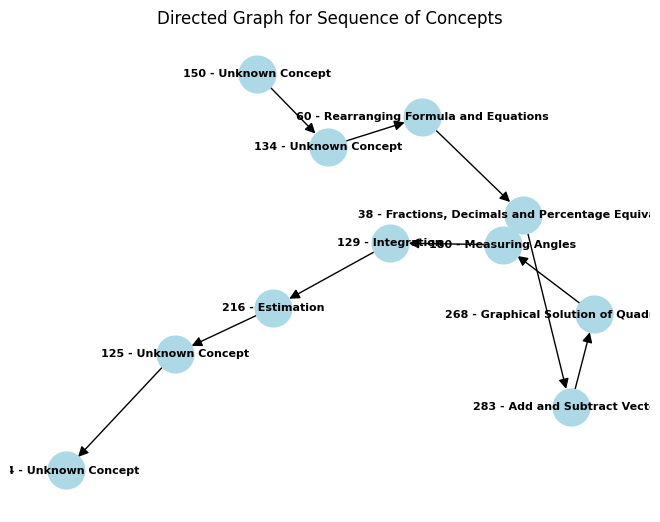

In [7]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Define a dictionary to map action numbers to action names
action_names = {
    0: 'Action_0',
    1: 'Action_1',
    # Add more action names as needed
}

# Load subject metadata from the CSV file
subject_metadata = pd.read_csv('subject_metadata.csv')

# Extract the relevant columns
concept_names = dict(zip(subject_metadata['SubjectId'], subject_metadata['Name']))

# Load the train data
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Get unique concepts from the train data
unique_concepts = train_data['Concept'].unique()

# Set the parameters
epsilon = 0.2  # Exploration-exploitation trade-off
alpha = 0.3  # Learning rate
gamma = 0.9  # Discount factor
concept_count = len(unique_concepts)  # Number of concepts

# Initialize Q-values
q_values = {(state, action): 0 for state in unique_concepts for action in unique_concepts}

# Variables to track accuracy and reward for each episode
episode_accuracies = []
episode_rewards = []

# Initialize lists to store average accuracy and total reward for each episode
average_accuracy_episodes = []
average_reward_episodes = []

# Initialize total accuracy and total reward for each episode
total_accuracy_episode = 0
total_reward_episode = 0

# Q-learning algorithm
num_episodes = 90  # Number of runs

for run in range(10):
    # Select 10 random concepts for the graph
    selected_concepts = random.sample(list(unique_concepts), 11)

    # Create a graph representing the chain of concepts
    graph = {selected_concepts[i]: selected_concepts[i + 1] for i in range(10)}

    # Initialize total accuracy and total reward for each episode
    total_accuracy_episode = 0
    total_reward_episode = 0

    for episode in range(num_episodes):
        state = selected_concepts[0]  # Initial state
        episode_accuracy = 0
        episode_reward = 0

        while state != selected_concepts[-1]:  # Continue until reaching the last state
            # Select 10 random questions related to the selected concept
            concept_questions = train_data[train_data['Concept'] == state]
            concept_questions = concept_questions.sample(10, replace=True)  # Select 10 questions randomly with replacement

            # Choose a random question from the selected questions
            question_data = concept_questions.sample(1).iloc[0]
            student_answer = question_data['AnswerValue']

            # Calculate reward based on correctness of the student's answer
            reward = 1 if question_data['IsCorrect'] == 1 else 0

            # Update total accuracy and total reward for each episode
            episode_accuracy += reward
            episode_reward += reward

            # Move to the next state
            state = graph[state]

        # Update total accuracy and total reward for each episode
        total_accuracy_episode += episode_accuracy / (len(selected_concepts) - 1)
        total_reward_episode += episode_reward
        average_accuracy_episode = total_accuracy_episode / (episode + 1)
        average_reward_episode = total_reward_episode / (episode + 1)

        # Append average accuracy and total reward to lists for plotting
        average_accuracy_episodes.append(average_accuracy_episode)
        average_reward_episodes.append(average_reward_episode)

        # Print accuracy and reward at the end of each episode
        print(f"Run: {run + 1}, Episode: {episode + 1}, Accuracy: {episode_accuracy}/{len(selected_concepts) - 1}={episode_accuracy / (len(selected_concepts) - 1):.1f}, Reward: {episode_reward}")

# Print average accuracy and average total reward at the end
print(f"\nAverage Accuracy Over Episodes: {average_accuracy_episode:.2f}")
print(f"Average Total Reward Over Episodes: {average_reward_episode:.2f}")

# Create a new figure for the combined accuracy and reward plot
plt.figure(figsize=(10, 5))

# Plot accuracy over episodes
plt.subplot(2, 1, 1)
plt.plot(average_accuracy_episodes, label='Average Accuracy')
plt.title(f'Accuracy and Reward Over Episodes\nAlgorithm: Random Questions, Episodes: {num_episodes}, Average Accuracy: {average_accuracy_episode:.2f}')

plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()

# Plot reward over episodes with orange color
plt.subplot(2, 1, 2)
plt.plot(average_reward_episodes, color='orange', label='Average Reward')
plt.title(f'\nAlgorithm: Random Questions, Episodes: {num_episodes}, Average Reward: {average_reward_episode:.2f}')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()

plt.tight_layout()
plt.show()

# Create the directed graph for the sequence of selected concepts
edges = [(selected_concepts[i], selected_concepts[i + 1]) for i in range(10)]
G = nx.DiGraph(edges)

# Plot the directed graph for the sequence of concepts
pos = nx.spring_layout(G)
labels = {concept: f"{concept} - {concept_names.get(concept, 'Unknown Concept')}" for concept in selected_concepts}
nx.draw(G, pos, with_labels=True, labels=labels, node_size=700, node_color='lightblue', font_size=8, font_color='black', font_weight='bold', arrowsize=15)
plt.title('Directed Graph for Sequence of Concepts')
plt.show()


Run: 1, Episode: 1, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 2, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 3, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 4, Accuracy: 6/10=0.6, Reward: 6
Run: 1, Episode: 5, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 6, Accuracy: 3/10=0.3, Reward: 3
Run: 1, Episode: 7, Accuracy: 6/10=0.6, Reward: 6
Run: 1, Episode: 8, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 9, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 10, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 11, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 12, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 13, Accuracy: 5/10=0.5, Reward: 5
Run: 1, Episode: 14, Accuracy: 3/10=0.3, Reward: 3
Run: 1, Episode: 15, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 16, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 17, Accuracy: 3/10=0.3, Reward: 3
Run: 1, Episode: 18, Accuracy: 4/10=0.4, Reward: 4
Run: 1, Episode: 19, Accuracy: 6/10=0.6, Reward: 6
Run: 1, Episode: 20, Accuracy: 3/10=0.3,

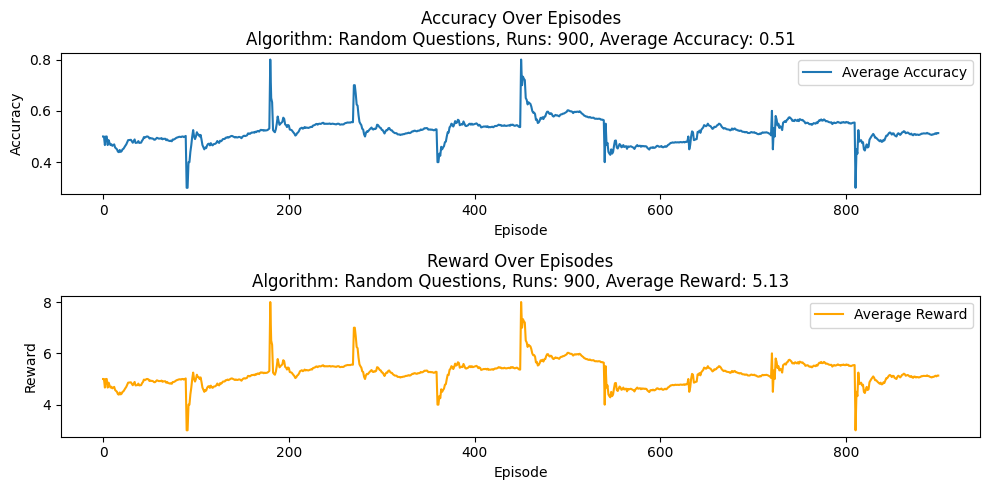

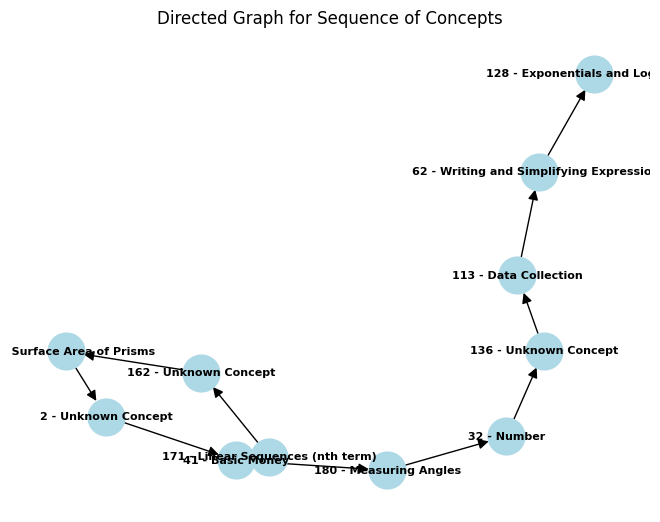

: 

In [8]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Define a dictionary to map action numbers to action names
action_names = {
    0: 'Action_0',
    1: 'Action_1',
    # Add more action names as needed
}

# Load subject metadata from the CSV file
subject_metadata = pd.read_csv('subject_metadata.csv')

# Extract the relevant columns
concept_names = dict(zip(subject_metadata['SubjectId'], subject_metadata['Name']))

# Load the train data
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Get unique concepts from the train data
unique_concepts = train_data['Concept'].unique()

# Set the parameters
epsilon = 0.2  # Exploration-exploitation trade-off
alpha = 0.3  # Learning rate
gamma = 0.9  # Discount factor
concept_count = len(unique_concepts)  # Number of concepts

# Variables to track accuracy and reward for each episode
episode_accuracies = []
episode_rewards = []

# Initialize lists to store average accuracy and total reward for each episode
average_accuracy_episodes = []
average_reward_episodes = []

# Initialize total accuracy and total reward for each episode
total_accuracy_episode = 0
total_reward_episode = 0

# Q-learning algorithm
num_episodes = 90  # Number of runs

for run in range(10):
    # Select 10 random concepts for the graph
    selected_concepts = random.sample(list(unique_concepts), 11)

    # Create a graph representing the chain of concepts
    graph = {selected_concepts[i]: selected_concepts[i + 1] for i in range(10)}

    # Initialize total accuracy and total reward for each episode
    total_accuracy_episode = 0
    total_reward_episode = 0

    for episode in range(num_episodes):
        state = selected_concepts[0]  # Initial state
        episode_accuracy = 0
        episode_reward = 0

        while state != selected_concepts[-1]:  # Continue until reaching the last state
            # Select 10 random questions related to the selected concept
            concept_questions = train_data[train_data['Concept'] == state]
            concept_questions = concept_questions.sample(10, replace=True)  # Select 10 questions randomly with replacement

            # Choose a random question from the selected questions
            question_data = concept_questions.sample(1).iloc[0]
            student_answer = question_data['AnswerValue']

            # Calculate reward based on correctness of the student's answer
            reward = 1 if question_data['IsCorrect'] == 1 else 0

            # Update total accuracy and total reward for each episode
            episode_accuracy += reward
            episode_reward += reward

            # Move to the next state
            state = graph[state]

        # Update total accuracy and total reward for each episode
        total_accuracy_episode += episode_accuracy / (len(selected_concepts) - 1)
        total_reward_episode += episode_reward
        average_accuracy_episode = total_accuracy_episode / (episode + 1)
        average_reward_episode = total_reward_episode / (episode + 1)

        # Append average accuracy and total reward to lists for plotting
        average_accuracy_episodes.append(average_accuracy_episode)
        average_reward_episodes.append(average_reward_episode)

        # Print accuracy and reward at the end of each episode
        print(f"Run: {run + 1}, Episode: {episode + 1}, Accuracy: {episode_accuracy}/{len(selected_concepts) - 1}={episode_accuracy / (len(selected_concepts) - 1):.1f}, Reward: {episode_reward}")

# Print average accuracy and average total reward at the end
print(f"\nAverage Accuracy Over Episodes: {average_accuracy_episode:.2f}")
print(f"Average Total Reward Over Episodes: {average_reward_episode:.2f}")

# Create a new figure for the combined accuracy and reward plot
plt.figure(figsize=(10, 5))

# Plot accuracy over episodes
plt.subplot(2, 1, 1)
plt.plot(average_accuracy_episodes, label='Average Accuracy')
plt.title(f'Accuracy Over Episodes\nAlgorithm: Random Questions, Runs: {num_episodes * 10}, Average Accuracy: {average_accuracy_episode:.2f}')

plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()

# Plot reward over episodes with orange color
plt.subplot(2, 1, 2)
plt.plot(average_reward_episodes, color='orange', label='Average Reward')
plt.title(f'Reward Over Episodes\nAlgorithm: Random Questions, Runs: {num_episodes * 10}, Average Reward: {average_reward_episode:.2f}')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()

plt.tight_layout()
plt.show()

# Create the directed graph for the sequence of selected concepts
edges = [(selected_concepts[i], selected_concepts[i + 1]) for i in range(10)]
G = nx.DiGraph(edges)

# Plot the directed graph for the sequence of concepts
pos = nx.spring_layout(G)
labels = {concept: f"{concept} - {concept_names.get(concept, 'Unknown Concept')}" for concept in selected_concepts}
nx.draw(G, pos, with_labels=True, labels=labels, node_size=700, node_color='lightblue', font_size=8, font_color='black', font_weight='bold', arrowsize=15)
plt.title('Directed Graph for Sequence of Concepts')
plt.show()
